# OCR Exploration — `deepseek-ocr`\n\nRunning the receipts in `notebooks/receipts/` through the local `deepseek-ocr:latest` model (vision capability) via the Ollama REST API.\n\nCovers plain free-form OCR and prompted structured extraction (merchant, date, line items, total) as JSON.\n\nMake sure the Ollama server is running (`ollama serve`) before executing cells.

In [1]:
import base64
import json
from pathlib import Path

import requests
from PIL import Image

BASE_URL = "http://localhost:11434"
OCR_MODEL = "deepseek-ocr:latest"

RECEIPTS_DIR = Path("receipts")
receipt_paths = sorted(RECEIPTS_DIR.glob("*.[jp][pn]g"))
[p.name for p in receipt_paths]

['1*N9w_Ck211Lo22lYbTd14aQ.jpg',
 'FE1DgHAWYAAwMgV.jpg',
 'Fake-Hotel-Receipt-Template.jpg',
 'fast-food-receipt-for-ice-cream-frozen-yogurt-custard-store1.png',
 'fast-food-restaurant-template-with-itemized-food-and-tax.png']

## Helper — run a prompt against an image

Encodes an image file as base64 and posts it to `/api/generate` alongside a prompt, same shape as the vision example in `ollama_exploration.ipynb`.

In [2]:
def image_to_b64(path: Path) -> str:
    return base64.b64encode(path.read_bytes()).decode()


def run_vision_prompt(model: str, image_path: Path, prompt: str, **options) -> str:
    resp = requests.post(
        f"{BASE_URL}/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "images": [image_to_b64(image_path)],
            "stream": False,
            **options,
        },
    )
    resp.raise_for_status()
    return resp.json()["response"]

## Preview the receipts

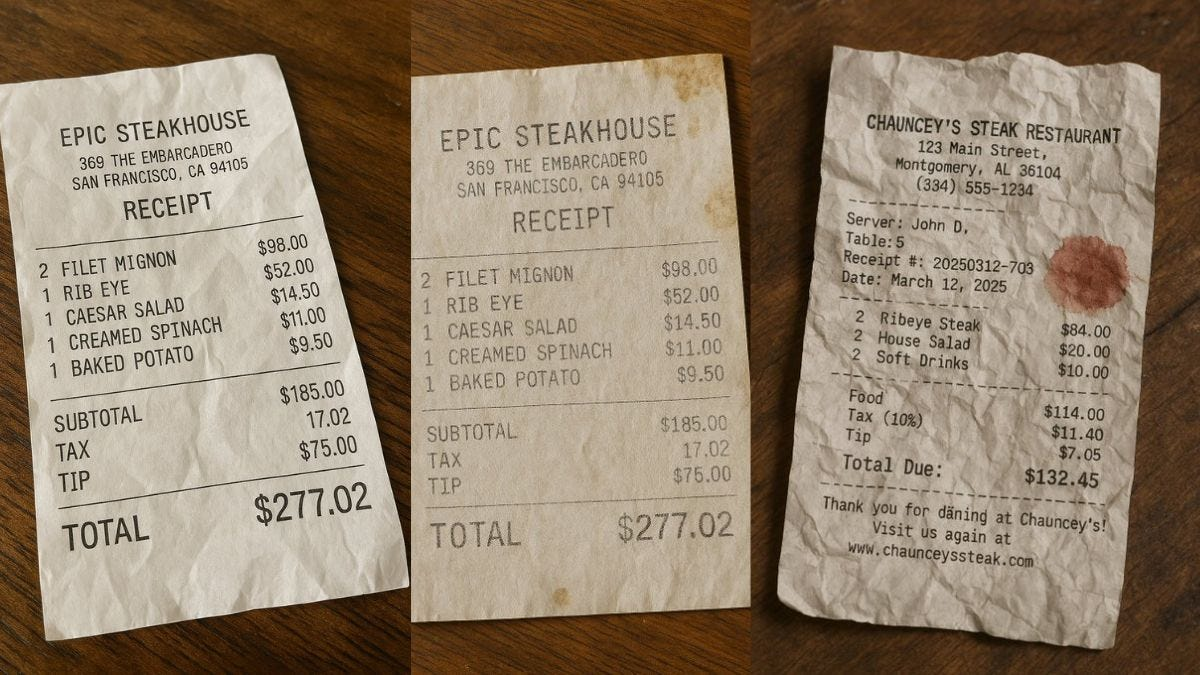

1*N9w_Ck211Lo22lYbTd14aQ.jpg


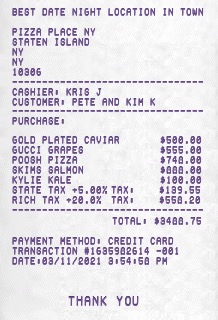

FE1DgHAWYAAwMgV.jpg


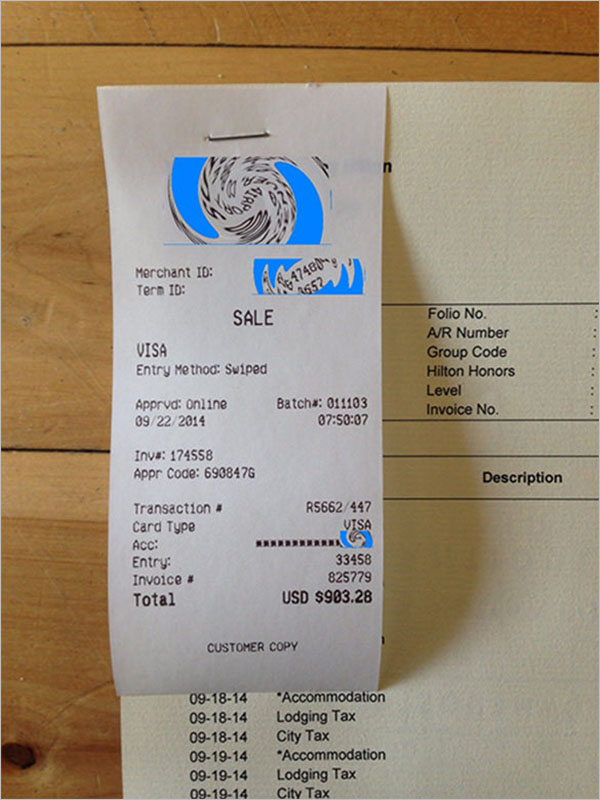

Fake-Hotel-Receipt-Template.jpg


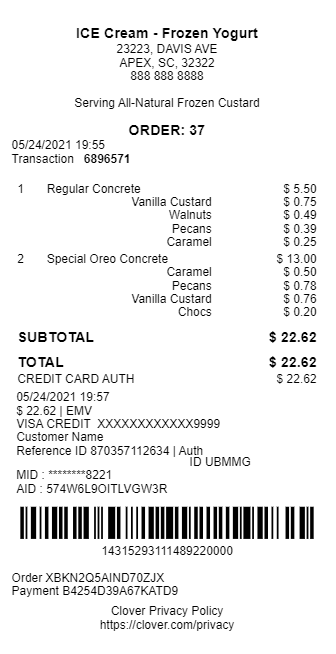

fast-food-receipt-for-ice-cream-frozen-yogurt-custard-store1.png


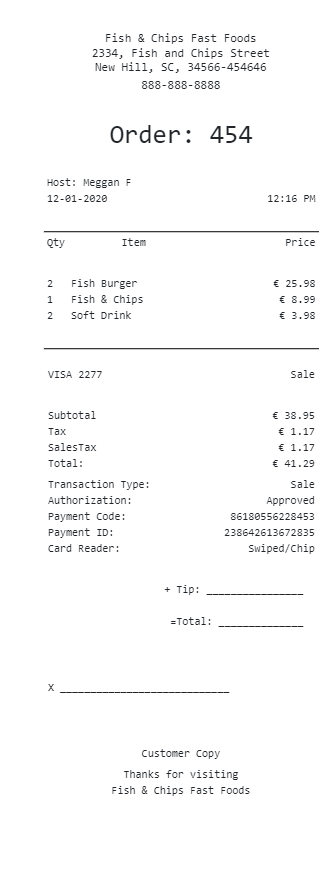

fast-food-restaurant-template-with-itemized-food-and-tax.png


In [3]:
for path in receipt_paths:
    display(Image.open(path))
    print(path.name)

## Free-form OCR across all receipts

`deepseek-ocr` supports a raw `"Free OCR."` prompt that dumps all detected text without any structuring.

In [4]:
for path in receipt_paths:
    text = run_vision_prompt(OCR_MODEL, path, "Free OCR.")
    print(f"=== {path.name} ===")
    print(text)
    print()

=== 1*N9w_Ck211Lo22lYbTd14aQ.jpg ===
# EPIC STEAKHOUSE

369 The Embarcadero  
SAN FRANCISCO, CA 94105  

**RECEIPT**

2 FILET MIGNON    $98.00  
1 RIB EYE    $52.00  
1 CAESAR SALAD    $14.50  
1 CREAMED SPINACH   $9.50  
1 BAKED POTATO    $185.00  

**SUBTOTAL**    17.02  
**TAX**    $75.00  
**TIP**    **$277.02**

**TOTAL**    **$277.02**

---

# EPIC STEAKHOUSE

369 The Embarcadero  
SAN FRANCISCO, CA 94105  

**RECEIPT**

2 FILET MIGNON    $98.00  
1 RIB EYE    $52.00  
1 CAESAR SALAD    $14.50  
1 CREAMED SPINACH   $11.00  
1 BAKED POTATO    $185.00  

**SUBTOTAL**    17.02  
**TAX**    $75.00  
**TIP**    **$277.02**

**TOTAL**    **$277.02**

---

# CHAUNCEY'S STEAK RESTAURANT

123 Main Street,  
Montgomery, AL 36104  

(334) 555-1234  

**Server:** John D.,  
Table: 5  
**Receipt #:** 20250312-703  
**Date:** March 12, 2025  

2 Ribeye Steak    $84.00  
2 House Salad    $20.00  
2 Soft Drinks    $10.00  

**Food**  
Tax (10%)    $114.00  
Tip    $11.40  
**Total Due:**    **$1

=== FE1DgHAWYAAwMgV.jpg ===
BEST DATE NIGHT LOCATION IN TOWN

PIZZA PLACE NY  
STATEN ISLAND  
NY  
10306  

---  
CASHIER: KRIS J  
CUSTOMER: PETE AND KIM K  

---  
PURCHASE:  

GOLD PLATED CAVIAR    $500.00  
GUCCI GRAPES    $555.00  
POOSH PIZZA    $740.00  
SKIMS SALMON    $800.00  
KYLIE KALE    $100.00  
STATE TAX +5.00% TAX:   $139.55  
RICH TAX +20.0% TAX:     $550.20  

---  
TOTAL: $3400.75  

PAYMENT METHOD: CREDIT CARD  
TRANSACTION #1685902614 -001  
DATE: 03/11/2021 3:54:50 PM  

THANK YOU



=== Fake-Hotel-Receipt-Template.jpg ===
Merchant ID:  
Term ID:  

SALE  

VISA  
Entry Method: Swiped  

Approved Online  
09/22/2014  

Batch#: 011103  
07:50:07  

Inv#: 174558  
Appr Code: 6908476  

Transaction #: RS662/447  
Card Type: USSA  
Acc:  
Entry: 33458  
Invoice #: 825779  
Total USD $903.28  

CUSTOMER COPY  

09-18-14 *Accommodation  
09-18-14 Lodging Tax  
09-18-14 City Tax  
09-19-14 *Accommodation  
09-19-14 Lodging Tax  
09-19-14 City Tax



=== fast-food-receipt-for-ice-cream-frozen-yogurt-custard-store1.png ===
ICE Cream - Frozen Yogurt  
23223, DAVIS AVE  
APEX, SC, 32322  
888 888 8888  

Serving All-Natural Frozen Custard  

**ORDER:** 37  
05/24/2021 19:55  
Transaction  6896571  

| Item | Description    | Price |
|---|---|---|
| 1    | Regular Concrete    | $ 5.50 |
|    | Vanilla Custard    | $ 0.75 |
|    | Walnuts    | $ 0.49 |
|    | Pecans    | $ 0.39 |
|    | Caramel    | $ 0.25 |

| 2    | Special Oreo Concrete   | $ 13.00|
|    | Caramel    | $ 0.50 |
|    | Pecans    | $ 0.78 |
|    | Vanilla Custard    | $ 0.76 |
|    | Chocs    | $ 0.20 |

**SUBTOTAL**  
$ 22.62  

**TOTAL**  
$ 22.62  

CREDIT CARD AUTH  
$ 22.62  

05/24/2021 19:57  
$ 22.62 | EMV  
VISA CREDIT XXXXXXXXXXXXX9999  
Customer Name  
Reference ID 870357112634 | Auth  
ID UBMMG  

MID : *******8221  
AID : 574W6L9OITLVGW3R  

14315293111489220000  

Order XBKN2Q5AIND70ZJX  
Payment B4254D39A67KATD9  

Clover Privacy Policy  
https://clover.

=== fast-food-restaurant-template-with-itemized-food-and-tax.png ===
Fish & Chips Fast Foods  
2334, Fish and Chips Street  
New Hill, SC, 34566-454646  
888-888-8888  

**Order: 454**

Host: Meggan F  
12-01-2020    12:16 PM  

| Qty | Item                | Price |
|-----|---------------------|-------|
| 2   | Fish Burger         | € 25.98 |
| 1   | Fish & Chips        | € 8.99  |
| 2   | Soft Drink          | € 3.98  |

VISA 2277    Sale  

Subtotal     € 38.95  
Tax            € 1.17  
SalesTax      € 1.17  
Total:       € 41.29  

Transaction Type: Sale  
Authorization: Approved  
Payment Code: 86180556228453  
Payment ID: 238642613672835  
Card Reader: Swiped/Chip  

+ Tip: ______________

=Total: ______________

X _________________________

Customer Copy  
Thanks for visiting  
Fish & Chips Fast Foods



## Structured extraction

Prompting for a specific JSON shape instead of raw OCR text — useful for turning a receipt photo into structured records.

In [5]:
EXTRACTION_PROMPT = (
    "Extract this receipt as JSON with keys: "
    '"merchant", "date", "items" (list of {"name", "price"}), "total". '
    "Respond with only the JSON object, no commentary."
)

extracted = {}
for path in receipt_paths:
    raw = run_vision_prompt(OCR_MODEL, path, EXTRACTION_PROMPT)
    try:
        data = json.loads(raw.strip().strip("`").removeprefix("json"))
    except json.JSONDecodeError:
        data = {"_raw": raw}
    extracted[path.name] = data
    print(f"=== {path.name} ===")
    print(json.dumps(data, indent=2))
    print()

=== 1*N9w_Ck211Lo22lYbTd14aQ.jpg ===
{
  "_raw": "The given text is a receipts from two different restaurants, Epic Steakhouse and Chauncey's Steak Restaurant. The receipt lists various food items and their prices along with the total amount due. The restaurant charges $98 for filet mignon, $52 for rib eye steak, and $14 for caesar salad. They also offer a baked potato for $9.50 and a subtotal of $185.00. The Chauncey's Steak Restaurant charges $123 for an item from the main street menu, with prices ranging from $334 to $555. The receipt includes the server's name, John D., table number 5, and date of March 12, 2025. It lists items such as ribeye steak, house salad, soft drinks, food tax, tip, and total due. The restaurant charges a total of $132.45."
}

=== FE1DgHAWYAAwMgV.jpg ===
{
  "_raw": ""
}



=== Fake-Hotel-Receipt-Template.jpg ===
{
  "_raw": ""
}



=== fast-food-receipt-for-ice-cream-frozen-yogurt-custard-store1.png ===
{
  "_raw": "The provided text is a screenshot of an online purchase transaction made on May 24, 2021. The order number is 37 and it was placed at 19:55. The items purchased include Regular Concrete (5.50), Vanilla Custard (0.75), Walnuts (0.49), Pecans (0.39), Caramel (0.25), Special Oreo Concrete (13.00), Caramel (0.50), Pecans (0.78), Vanilla Custard (0.76), and Chocs (0.20). The total cost of the order is $22.62, which includes a credit card charge for EMV Visa Credit XXXXXXXXXXXXX9999 with customer name, reference ID 870357112634, and auth ID UBMMG. The transaction also shows an AID of 574W6L9OITLVGW3R."
}



=== fast-food-restaurant-template-with-itemized-food-and-tax.png ===
{
  "merchant": "Fish & Chips Fast Foods",
  "date": "12-01-2020",
  "items": [
    {
      "name": "Fish Burger",
      "price": 25.98
    },
    {
      "name": "Fish & Chips",
      "price": 8.99
    },
    {
      "name": "Soft Drink",
      "price": 3.98
    }
  ],
  "total": 41.29,
  "transaction_type": "Sale",
  "authorization": "Approved",
  "payment_code": "86180556228453",
  "payment_id": "238642613672835",
  "card_reader": "Swiped/Chip"
}



## Notes

- `deepseek-ocr` is OCR-specialized: the `"Free OCR."` prompt is a model-specific convention that yields raw transcribed text with minimal formatting drift.
- Structured extraction quality depends heavily on prompt wording and image quality (skew, resolution, receipt template) — inspect `extracted` above for any `_raw` fallback entries where JSON parsing failed.
- For a general-purpose vision model's take on the same receipts (rather than an OCR specialist), see `gemma4_exploration.ipynb`.